In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import os
import re

import sklearn
import sklearn.datasets
import sklearn.model_selection
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import tensorflow as tf

# Use keras 2
import tf_keras as tfk
os.environ["TF_USE_LEGACY_KERAS"] ="1"

## Use keras 3
#tfk = tf.keras

from normalizing_flow import MAF

In [2]:
os.environ["CUDA_VISIBLE_DEVICES"]="0"

In [3]:
mnist = fetch_openml("mnist_784")

9


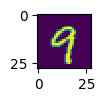

In [4]:
YY=mnist['target'].to_numpy().astype(int)
XX2D=mnist['data'].to_numpy()
nid=580
plt.figure(figsize=(0.7,0.7))
plt.imshow(XX2D[nid].reshape((28,28)), interpolation='nearest')
print(YY[nid])

In [5]:
# binarize
#XX2D[XX2D != 0 ] = 1

3


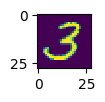

In [6]:
XX = [np.squeeze( XX2D[n].reshape((len(XX2D[n]), -1)) ) for n in range(len(XX2D))]
nid=405
plt.figure(figsize=(0.7,0.7))
plt.imshow(XX[nid].reshape((28,28)), interpolation='nearest')
print(YY[nid])

In [7]:
xx_train, xx_test, yy_train, yy_test = sklearn.model_selection.train_test_split(XX, YY)

al = 1.0
xx_train = np.array([(xx_train[i] + al*np.random.rand(xx_train[i].shape[0]))/256.0 for i in np.arange(yy_train.size)])
xx_test  = np.array([( xx_test[i] + al*np.random.rand( xx_test[i].shape[0]))/256.0 for i in np.arange( yy_test.size)])

def logit(x):
    return np.log(x / (1 - x))

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

l = 1.0e-6
xx_train = logit(l+(1.0-2.0*l)*xx_train)
xx_test  = logit(l+(1.0-2.0*l)*xx_test)

def ohe(x):
    vec = np.zeros(10)
    vec[x] = 1.0
    return vec

data_train = np.array([np.append(xx_train[i], ohe(yy_train[i])) for i in np.arange(yy_train.size)])
data_test  = np.array([np.append(xx_test[i], ohe(yy_test[i])) for i in np.arange(yy_test.size)])

In [8]:
nvars = 784
ncondvars = 10
nflow = MAF(nvars, ncondvars, nblocks=5, hidden_units=[1024, 1024, 1024], activation='relu', last_activation='relu', l1=0.0, l2=1.0e-6)

#print(nflow.trainable_variables)

nflow.compile(optimizer=tfk.optimizers.Adam(learning_rate=1.0e-4), loss=lambda _, log_prob: -log_prob)


2025-10-23 15:09:51.227859: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 37644 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:25:00.0, compute capability: 8.0


In [9]:
batch_size=1024
nflow.fit(x=[data_train[:,:nvars], data_train[:,nvars:nvars+ncondvars]],
          y=np.zeros((data_train.shape[0], 0), dtype=np.float32),
          batch_size=batch_size,
          epochs=500,
          steps_per_epoch=data_train.shape[0] // batch_size,
          shuffle=True,
          verbose=True,
          validation_data=([data_test[:,:nvars], data_test[:,nvars:nvars+ncondvars]],np.zeros((data_test.shape[0], 0), dtype=np.float32)),
          callbacks=[tfk.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=30, restore_best_weights=True)])


Epoch 1/500


2025-10-23 15:10:38.895324: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f596d306010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-23 15:10:38.895383: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB, Compute Capability 8.0
2025-10-23 15:10:38.900549: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-23 15:10:38.916569: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2025-10-23 15:10:39.005814: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


51/51 [==============================] - 53s 58ms/step - loss: 7141.4126 - val_loss: 2407.0698
Epoch 2/500
51/51 [==============================] - 2s 33ms/step - loss: 2085.4883 - val_loss: 1897.5439
Epoch 3/500
51/51 [==============================] - 2s 33ms/step - loss: 1824.4194 - val_loss: 1772.4767
Epoch 4/500
51/51 [==============================] - 2s 33ms/step - loss: 1741.2423 - val_loss: 1712.5082
Epoch 5/500
51/51 [==============================] - 2s 33ms/step - loss: 1688.9037 - val_loss: 1667.9729
Epoch 6/500
51/51 [==============================] - 2s 33ms/step - loss: 1651.7942 - val_loss: 1636.5212
Epoch 7/500
51/51 [==============================] - 2s 33ms/step - loss: 1622.7108 - val_loss: 1609.8557
Epoch 8/500
51/51 [==============================] - 2s 33ms/step - loss: 1600.0387 - val_loss: 1590.9359
Epoch 9/500
51/51 [==============================] - 2s 33ms/step - loss: 1582.9314 - val_loss: 1574.7678
Epoch 10/500
51/51 [==============================] - 2s 

Epoch 78/500
51/51 [==============================] - 2s 33ms/step - loss: 1369.3071 - val_loss: 1373.4583
Epoch 79/500
51/51 [==============================] - 2s 33ms/step - loss: 1369.3712 - val_loss: 1372.6323
Epoch 80/500
51/51 [==============================] - 2s 33ms/step - loss: 1367.3623 - val_loss: 1372.2572
Epoch 81/500
51/51 [==============================] - 2s 33ms/step - loss: 1367.3558 - val_loss: 1370.6956
Epoch 82/500
51/51 [==============================] - 2s 33ms/step - loss: 1365.7251 - val_loss: 1370.3696
Epoch 83/500
51/51 [==============================] - 2s 33ms/step - loss: 1365.5942 - val_loss: 1369.4705
Epoch 84/500
51/51 [==============================] - 2s 31ms/step - loss: 1364.9390 - val_loss: 1369.4812
Epoch 85/500
51/51 [==============================] - 2s 33ms/step - loss: 1363.6382 - val_loss: 1368.2184
Epoch 86/500
51/51 [==============================] - 2s 33ms/step - loss: 1363.2802 - val_loss: 1367.3744
Epoch 87/500
51/51 [=================

51/51 [==============================] - 2s 32ms/step - loss: 1324.5746 - val_loss: 1334.1307
Epoch 155/500
51/51 [==============================] - 2s 32ms/step - loss: 1323.8513 - val_loss: 1333.9004
Epoch 156/500
51/51 [==============================] - 2s 34ms/step - loss: 1323.5615 - val_loss: 1333.1029
Epoch 157/500
51/51 [==============================] - 2s 33ms/step - loss: 1323.3905 - val_loss: 1332.0880
Epoch 158/500
51/51 [==============================] - 2s 33ms/step - loss: 1322.7598 - val_loss: 1332.0096
Epoch 159/500
51/51 [==============================] - 2s 33ms/step - loss: 1322.4724 - val_loss: 1330.8212
Epoch 160/500
51/51 [==============================] - 2s 32ms/step - loss: 1321.8258 - val_loss: 1330.8901
Epoch 161/500
51/51 [==============================] - 2s 34ms/step - loss: 1321.4410 - val_loss: 1330.6138
Epoch 162/500
51/51 [==============================] - 2s 33ms/step - loss: 1320.8125 - val_loss: 1330.3641
Epoch 163/500
51/51 [=====================

Epoch 230/500
51/51 [==============================] - 2s 34ms/step - loss: 1296.9604 - val_loss: 1310.9783
Epoch 231/500
51/51 [==============================] - 2s 32ms/step - loss: 1296.8358 - val_loss: 1311.1316
Epoch 232/500
51/51 [==============================] - 2s 34ms/step - loss: 1296.7797 - val_loss: 1310.9545
Epoch 233/500
51/51 [==============================] - 2s 34ms/step - loss: 1295.4344 - val_loss: 1310.5549
Epoch 234/500
51/51 [==============================] - 2s 34ms/step - loss: 1296.4932 - val_loss: 1310.3240
Epoch 235/500
51/51 [==============================] - 2s 34ms/step - loss: 1295.3048 - val_loss: 1310.1367
Epoch 236/500
51/51 [==============================] - 2s 34ms/step - loss: 1295.1064 - val_loss: 1309.8969
Epoch 237/500
51/51 [==============================] - 2s 33ms/step - loss: 1294.9255 - val_loss: 1309.7178
Epoch 238/500
51/51 [==============================] - 2s 34ms/step - loss: 1294.1720 - val_loss: 1309.5718
Epoch 239/500
51/51 [=======

Epoch 306/500
51/51 [==============================] - 2s 33ms/step - loss: 1276.7935 - val_loss: 1297.3074
Epoch 307/500
51/51 [==============================] - 2s 32ms/step - loss: 1276.0741 - val_loss: 1296.9918
Epoch 308/500
51/51 [==============================] - 2s 32ms/step - loss: 1275.9712 - val_loss: 1297.1862
Epoch 309/500
51/51 [==============================] - 2s 31ms/step - loss: 1275.6676 - val_loss: 1297.9149
Epoch 310/500
51/51 [==============================] - 2s 32ms/step - loss: 1275.7258 - val_loss: 1297.1887
Epoch 311/500
51/51 [==============================] - 2s 33ms/step - loss: 1275.3230 - val_loss: 1297.0713
Epoch 312/500
51/51 [==============================] - 2s 34ms/step - loss: 1275.0347 - val_loss: 1296.5959
Epoch 313/500
51/51 [==============================] - 2s 33ms/step - loss: 1274.9187 - val_loss: 1296.2059
Epoch 314/500
51/51 [==============================] - 2s 33ms/step - loss: 1274.6101 - val_loss: 1295.8199
Epoch 315/500
51/51 [=======

Epoch 382/500
51/51 [==============================] - 2s 32ms/step - loss: 1260.1348 - val_loss: 1288.8340
Epoch 383/500
51/51 [==============================] - 2s 32ms/step - loss: 1259.5494 - val_loss: 1289.5708
Epoch 384/500
51/51 [==============================] - 2s 32ms/step - loss: 1259.3518 - val_loss: 1288.8862
Epoch 385/500
51/51 [==============================] - 2s 32ms/step - loss: 1259.4899 - val_loss: 1289.0842
Epoch 386/500
51/51 [==============================] - 2s 32ms/step - loss: 1259.0386 - val_loss: 1288.9756
Epoch 387/500
51/51 [==============================] - 2s 32ms/step - loss: 1258.6063 - val_loss: 1289.1201
Epoch 388/500
51/51 [==============================] - 2s 34ms/step - loss: 1259.1202 - val_loss: 1288.1104
Epoch 389/500
51/51 [==============================] - 2s 32ms/step - loss: 1258.2302 - val_loss: 1289.3999
Epoch 390/500
51/51 [==============================] - 2s 32ms/step - loss: 1258.4739 - val_loss: 1289.0105
Epoch 391/500
51/51 [=======

Epoch 458/500
51/51 [==============================] - 2s 31ms/step - loss: 1245.7638 - val_loss: 1285.0277
Epoch 459/500
51/51 [==============================] - 2s 31ms/step - loss: 1245.3127 - val_loss: 1285.7522
Epoch 460/500
51/51 [==============================] - 2s 32ms/step - loss: 1245.5894 - val_loss: 1285.7844
Epoch 461/500
51/51 [==============================] - 2s 32ms/step - loss: 1245.1541 - val_loss: 1285.1448
Epoch 462/500
51/51 [==============================] - 2s 31ms/step - loss: 1244.7538 - val_loss: 1285.4690
Epoch 463/500
51/51 [==============================] - 2s 33ms/step - loss: 1244.9182 - val_loss: 1284.6282
Epoch 464/500
51/51 [==============================] - 2s 32ms/step - loss: 1244.6488 - val_loss: 1285.0393
Epoch 465/500
51/51 [==============================] - 2s 31ms/step - loss: 1244.4587 - val_loss: 1285.2704
Epoch 466/500
51/51 [==============================] - 2s 31ms/step - loss: 1244.2667 - val_loss: 1286.2119
Epoch 467/500
51/51 [=======

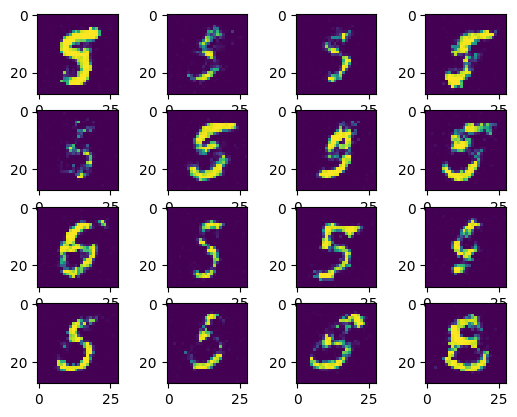

In [10]:
nsamples = 160

cond = 5
cond = ohe(cond)

samples = nflow.sample(cond, nsamples)

samples = sigmoid(samples)*256.0

plt.figure()
for n in np.arange(16):
    plt.subplot(4,4,1+n)
    sample = samples[n].reshape((28,28))
    plt.imshow(sample, interpolation='nearest')
    #plt.imshow(sample)

In [11]:
nflow.save_weights('my_model.weights')